# Population-weighted SIMD groupings from processed Scotland data

This notebook creates population-weighted SIMD groupings from the processed Scotland Data Zone lookup exposed by `utils.data`.

The key idea is:

> Sort Data Zones from most deprived to least deprived, then divide them into groups containing approximately equal shares of the population.

This differs from simply putting the same number of Data Zones into each group, because Data Zones have different population sizes.

## What this notebook does

1. Load real Data Zone SIMD ranks, existing SIMD quintiles, populations, and NHS Boards via `utils.data.load_datazone_info()`.
2. Build unweighted and population-weighted national SIMD quintiles.
3. Compare existing SIMD quintiles with the population-weighted assignments.
4. Plot the relationship between SIMD rank, population, cumulative population, and group assignment.
5. Build population-weighted quintiles within NHS Board.
6. Merge the grouping back onto real sequence-level records loaded via `utils.data.load_analysis_columns()`.


In [46]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import load_analysis_columns, load_datazone_info  # noqa: E402

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 1. Load real Data Zone SIMD data

The Data Zone lookup is read from the processed geography parquet configured in `config.yaml`. `load_datazone_info()` currently returns `datazone` as the index for this parquet, so the notebook resets the index before analysis.

The working table keeps concise column names used by the grouping functions:

- `datazone`
- `simd_rank`, where 1 is most deprived
- `population`
- `simd_quintile_source`, the existing SIMD quintile in the processed lookup
- `nhs_board`


In [47]:
DATAZONE_COLUMNS = [
    "dz_population",
    "dz_simd_rank",
    "dz_simd_quintile",
    "dz_simd_decile",
    "dz_health_board",
    "dz_health_board_code",
    "dz_local_authority",
]

datazone_lookup = load_datazone_info(DATAZONE_COLUMNS)
if "datazone" not in datazone_lookup.columns:
    datazone_lookup = datazone_lookup.reset_index()

df = (
    datazone_lookup
    .drop(columns="geometry", errors="ignore")
    .rename(columns={
        "dz_population": "population",
        "dz_simd_rank": "simd_rank",
        "dz_simd_quintile": "simd_quintile_source",
        "dz_simd_decile": "simd_decile_source",
        "dz_health_board": "nhs_board",
        "dz_health_board_code": "nhs_board_code",
        "dz_local_authority": "local_authority",
    })
    .dropna(subset=["datazone", "simd_rank", "population"])
    .copy()
)

df["simd_rank"] = pd.to_numeric(df["simd_rank"]).astype("int64")
df["population"] = pd.to_numeric(df["population"]).astype("int64")
df["simd_quintile_source"] = pd.to_numeric(df["simd_quintile_source"]).astype("int64")
df["simd_decile_source"] = pd.to_numeric(df["simd_decile_source"]).astype("int64")

df = df.sort_values("simd_rank").reset_index(drop=True)

df.head()

,datazone,nhs_board_code,local_authority,simd_rank,simd_quintile_source,nhs_board,population,simd_decile_source
0,S01010891,S08000031,Inverclyde,1,1,Greater Glasgow and Clyde,446,1
1,S01010245,S08000031,Glasgow City,2,1,Greater Glasgow and Clyde,796,1
2,S01011598,S08000032,North Lanarkshire,3,1,Lanarkshire,801,1
3,S01012068,S08000031,Renfrewshire,4,1,Greater Glasgow and Clyde,480,1
4,S01010122,S08000031,Glasgow City,5,1,Greater Glasgow and Clyde,511,1


In [48]:
df[[
    "datazone",
    "simd_rank",
    "population",
    "simd_quintile_source",
    "simd_decile_source",
    "nhs_board",
    "local_authority",
]].describe(include="all")

,datazone,simd_rank,population,simd_quintile_source,simd_decile_source,nhs_board,local_authority
count,6976,6976.000000,6976.000000,6976.000000,6976.000000,6976,6976
unique,6976,NaN,NaN,NaN,NaN,14,32
top,S01010891,NaN,NaN,NaN,NaN,Greater Glasgow and Clyde,Glasgow City
freq,1,NaN,NaN,NaN,NaN,1458,746
mean,NaN,3488.500000,777.637615,3.000287,5.500573,NaN,NaN
std,NaN,2013.942071,219.108923,1.414416,2.872487,NaN,NaN
min,NaN,1.000000,0.000000,1.000000,1.000000,NaN,NaN
25%,NaN,1744.750000,635.000000,2.000000,3.000000,NaN,NaN
50%,NaN,3488.500000,755.000000,3.000000,5.500000,NaN,NaN
75%,NaN,5232.250000,886.000000,4.000000,8.000000,NaN,NaN


## 2. Functions for unweighted and population-weighted grouping

The unweighted method cuts Data Zones into groups of approximately equal size by SIMD rank.

The population-weighted method cuts the cumulative population distribution into groups of approximately equal population size.

For SIMD-style interpretation:

- group 1 = most deprived
- group 5 = least deprived, if using quintiles
- group 10 = least deprived, if using deciles


In [49]:
def make_unweighted_groups(
    df,
    rank_col="simd_rank",
    n_groups=5,
    group_col="simd_quintile_unweighted",
):
    """
    Create deprivation groups using equal numbers of Data Zones.

    Group 1 is most deprived.
    Group n is least deprived.
    """
    out = df.copy()

    if out[rank_col].isna().any():
        raise ValueError(f"Missing values found in {rank_col}")

    out = out.sort_values(rank_col, ascending=True)

    # Assign groups by position in the ordered ranks to get (approximately) equal
    # numbers of Data Zones per group without relying on pd.qcut (avoids retbins error).
    n = len(out)
    if n == 0:
        out[group_col] = []
    else:
        ranks = out[rank_col].rank(method="first")
        out[group_col] = np.ceil(ranks * n_groups / n).astype(int)
        out[group_col] = out[group_col].clip(1, n_groups)

    return out


def make_population_weighted_groups(
    df,
    rank_col="simd_rank",
    pop_col="population",
    n_groups=5,
    group_col="simd_quintile_pop_weighted",
):
    """
    Create population-weighted deprivation groups.

    Data Zones are sorted from most deprived to least deprived.
    Groups are assigned using cumulative population share.

    Group 1 is most deprived.
    Group n is least deprived.
    """
    out = df.copy()

    if out[rank_col].isna().any():
        raise ValueError(f"Missing values found in {rank_col}")

    if out[pop_col].isna().any():
        raise ValueError(f"Missing values found in {pop_col}")

    if (out[pop_col] < 0).any():
        raise ValueError(f"Negative values found in {pop_col}")

    total_pop = out[pop_col].sum()

    if total_pop <= 0:
        raise ValueError("Total population must be greater than zero")

    out = out.sort_values(rank_col, ascending=True)
    out["cum_pop"] = out[pop_col].cumsum()
    out["cum_prop"] = out["cum_pop"] / total_pop

    out[group_col] = np.ceil(out["cum_prop"] * n_groups).astype(int)
    out[group_col] = out[group_col].clip(1, n_groups)

    return out

## 3. Create source, unweighted, and population-weighted SIMD quintiles

`simd_quintile_source` is the existing quintile in the processed SIMD lookup.

`simd_quintile_unweighted` is recomputed from the SIMD rank using equal numbers of Data Zones.

`simd_quintile_pop_weighted` is the new population-weighted grouping.


In [71]:
df_grouped = make_unweighted_groups(
    df,
    rank_col="simd_rank",
    n_groups=5,
    group_col="simd_quintile_unweighted",
)

df_grouped = make_population_weighted_groups(
    df_grouped,
    rank_col="simd_rank",
    pop_col="population",
    n_groups=5,
    group_col="simd_quintile_pop_weighted",
)
assert all(df_grouped["simd_quintile_unweighted"] == df_grouped["simd_quintile_source"])

df_grouped.head(10)


,datazone,nhs_board_code,local_authority,simd_rank,simd_quintile_source,nhs_board,population,simd_decile_source,simd_quintile_unweighted,cum_pop,cum_prop,simd_quintile_pop_weighted
0,S01010891,S08000031,Inverclyde,1,1,Greater Glasgow and Clyde,446,1,1,446,0.000082,1
1,S01010245,S08000031,Glasgow City,2,1,Greater Glasgow and Clyde,796,1,1,1242,0.000229,1
2,S01011598,S08000032,North Lanarkshire,3,1,Lanarkshire,801,1,1,2043,0.000377,1
3,S01012068,S08000031,Renfrewshire,4,1,Greater Glasgow and Clyde,480,1,1,2523,0.000465,1
4,S01010122,S08000031,Glasgow City,5,1,Greater Glasgow and Clyde,511,1,1,3034,0.000559,1
5,S01007465,S08000019,Clackmannanshire,6,1,Forth Valley,746,1,1,3780,0.000697,1
6,S01009622,S08000029,Fife,7,1,Fife,646,1,1,4426,0.000816,1
7,S01010644,S08000022,Highland,8,1,Highland,672,1,1,5098,0.000940,1
8,S01012067,S08000031,Renfrewshire,9,1,Greater Glasgow and Clyde,530,1,1,5628,0.001037,1
9,S01007801,S08000030,Dundee City,10,1,Tayside,943,1,1,6571,0.001211,1


False

## 4. Compare population distribution by grouping method

A good population-weighted quintile grouping should contain close to 20% of the total population in each group.

The existing SIMD quintile and the unweighted recomputation contain approximately 20% of Data Zones in each group, but not necessarily 20% of the population.


In [51]:
def summarise_groups(df, group_col, pop_col="population"):
    summary = (
        df.groupby(group_col)
        .agg(
            n_datazones=("datazone", "count"),
            total_population=(pop_col, "sum"),
            mean_population=(pop_col, "mean"),
            min_simd_rank=("simd_rank", "min"),
            max_simd_rank=("simd_rank", "max"),
        )
        .reset_index()
    )

    summary["pct_datazones"] = summary["n_datazones"] / summary["n_datazones"].sum() * 100
    summary["pct_population"] = summary["total_population"] / summary["total_population"].sum() * 100

    return summary


summary_source = summarise_groups(df_grouped, "simd_quintile_source")
summary_unweighted = summarise_groups(df_grouped, "simd_quintile_unweighted")
summary_pop_weighted = summarise_groups(df_grouped, "simd_quintile_pop_weighted")

summary_source

,simd_quintile_source,n_datazones,total_population,mean_population,min_simd_rank,max_simd_rank,pct_datazones,pct_population
0,1,1395,1059288,759.346237,1,1395,19.997133,19.526766
1,2,1395,1059104,759.214337,1396,2790,19.997133,19.523374
2,3,1395,1072629,768.909677,2791,4185,19.997133,19.772692
3,4,1395,1110521,796.072401,4186,5580,19.997133,20.471188
4,5,1396,1123258,804.626074,5581,6976,20.011468,20.705980


In [52]:
summary_pop_weighted

,simd_quintile_pop_weighted,n_datazones,total_population,mean_population,min_simd_rank,max_simd_rank,pct_datazones,pct_population
0,1,1429,1084654,759.030091,1,1429,20.484518,19.994359
1,2,1428,1085009,759.810224,1430,2857,20.470183,20.000903
2,3,1411,1084507,768.608788,2858,4268,20.226491,19.991649
3,4,1357,1085043,799.589536,4269,5625,19.452408,20.001530
4,5,1351,1085587,803.543301,5626,6976,19.366399,20.011558


## 5. Plot population share by quintile

The first plot shows how much population falls into each existing SIMD quintile from the processed lookup.

The second plot shows the population share after population weighting.

In an ideal population-weighted quintile scheme, each group is close to 20% of the population. Exact equality is rarely possible because Data Zones are indivisible units.


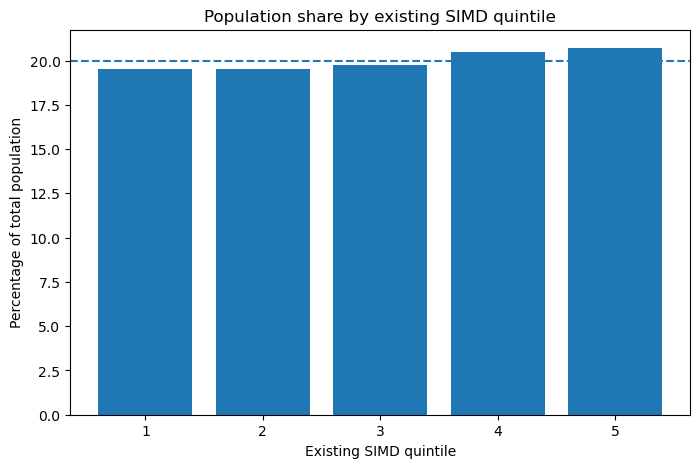

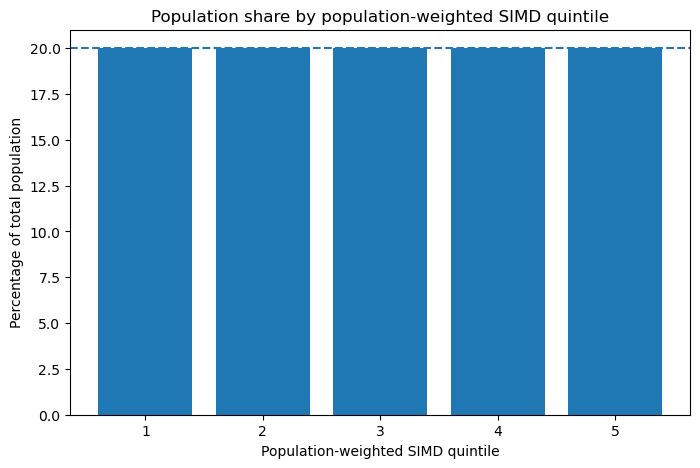

In [53]:
plot_data_source = summary_source.copy()
plot_data_pop_weighted = summary_pop_weighted.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_data_source["simd_quintile_source"], plot_data_source["pct_population"])
plt.axhline(20, linestyle="--")
plt.xlabel("Existing SIMD quintile")
plt.ylabel("Percentage of total population")
plt.title("Population share by existing SIMD quintile")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_data_pop_weighted["simd_quintile_pop_weighted"], plot_data_pop_weighted["pct_population"])
plt.axhline(20, linestyle="--")
plt.xlabel("Population-weighted SIMD quintile")
plt.ylabel("Percentage of total population")
plt.title("Population share by population-weighted SIMD quintile")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

## 6. Compare source and population-weighted group assignments

This table shows how Data Zones move between the existing SIMD quintile in the processed lookup and the population-weighted version.

If populations are unevenly distributed across SIMD rank, some Data Zones will move between quintiles.


In [54]:
movement_table = pd.crosstab(
    df_grouped["simd_quintile_source"],
    df_grouped["simd_quintile_pop_weighted"],
    rownames=["Existing SIMD quintile"],
    colnames=["Population-weighted quintile"],
)

movement_table

Population-weighted quintile,1,2,3,4,5
Existing SIMD quintile,,,,,
1,1395,0,0,0,0
2,34,1361,0,0,0
3,0,67,1328,0,0
4,0,0,83,1312,0
5,0,0,0,45,1351


In [55]:
df_grouped["quintile_change"] = (
    df_grouped["simd_quintile_pop_weighted"]
    - df_grouped["simd_quintile_source"]
)

change_summary = (
    df_grouped["quintile_change"]
    .value_counts()
    .sort_index()
    .rename_axis("change_in_quintile")
    .reset_index(name="n_datazones")
)

change_summary["pct_datazones"] = change_summary["n_datazones"] / len(df_grouped) * 100

change_summary


,change_in_quintile,n_datazones,pct_datazones
0,-1,229,3.282683
1,0,6747,96.717317


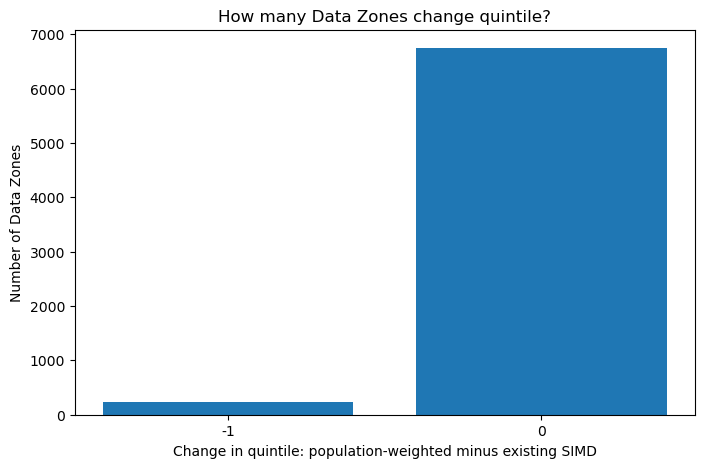

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(change_summary["change_in_quintile"].astype(str), change_summary["n_datazones"])
plt.xlabel("Change in quintile: population-weighted minus existing SIMD")
plt.ylabel("Number of Data Zones")
plt.title("How many Data Zones change quintile?")
plt.show()


## 7. Visualise population and cumulative population by SIMD rank

This plot shows why population weighting matters.

The cumulative population curve determines where the population-weighted quintile boundaries fall.


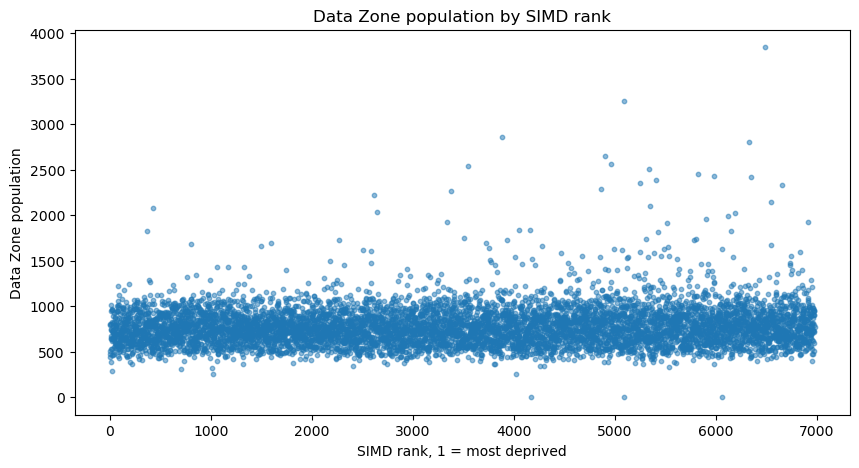

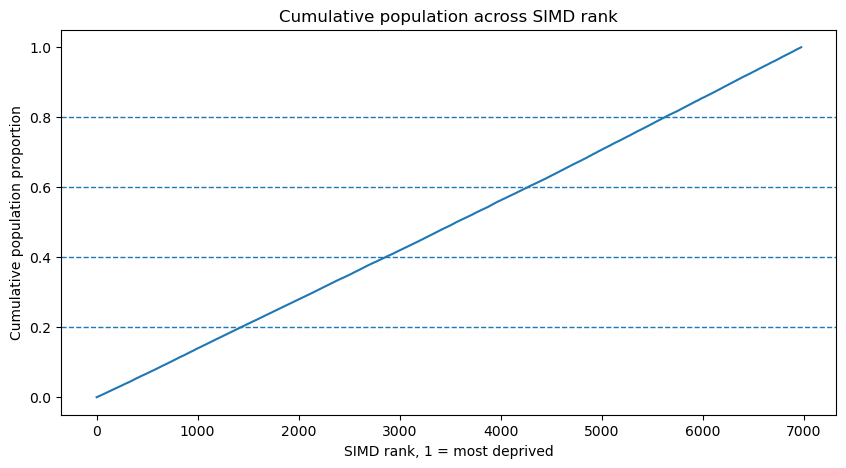

In [59]:
df_plot = df_grouped.sort_values("simd_rank").copy()

plt.figure(figsize=(10, 5))
plt.scatter(df_plot["simd_rank"], df_plot["population"], s=10, alpha=0.5)
plt.xlabel("SIMD rank, 1 = most deprived")
plt.ylabel("Data Zone population")
plt.title("Data Zone population by SIMD rank")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_plot["simd_rank"], df_plot["cum_prop"])
for boundary in [0.2, 0.4, 0.6, 0.8]:
    plt.axhline(boundary, linestyle="--", linewidth=1)
plt.xlabel("SIMD rank, 1 = most deprived")
plt.ylabel("Cumulative population proportion")
plt.title("Cumulative population across SIMD rank")
plt.show()

## 8. Where are the new population-weighted boundaries?

This table shows the approximate SIMD rank boundaries where the cumulative population passes 20%, 40%, 60%, 80%, and 100%.


In [60]:
boundary_table = (
    df_grouped
    .groupby("simd_quintile_pop_weighted")
    .agg(
        first_rank=("simd_rank", "min"),
        last_rank=("simd_rank", "max"),
        n_datazones=("datazone", "count"),
        total_population=("population", "sum"),
    )
    .reset_index()
)

boundary_table["pct_population"] = (
    boundary_table["total_population"]
    / boundary_table["total_population"].sum()
    * 100
)

boundary_table

,simd_quintile_pop_weighted,first_rank,last_rank,n_datazones,total_population,pct_population
0,1,1,1429,1429,1084654,19.994359
1,2,1430,2857,1428,1085009,20.000903
2,3,2858,4268,1411,1084507,19.991649
3,4,4269,5625,1357,1085043,20.001530
4,5,5626,6976,1351,1085587,20.011558


## 9. Relationship between source grouping, new grouping, and population

This plot shows each Data Zone as a point, with its existing and population-weighted quintile assignment.

Points away from the diagonal are Data Zones whose quintile changes after population weighting.


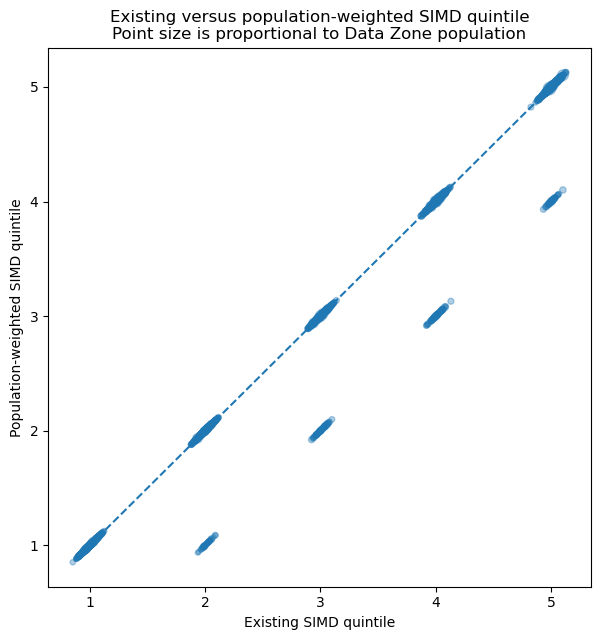

In [61]:
jitter = rng.normal(0, 0.04, size=len(df_grouped))

plt.figure(figsize=(7, 7))
plt.scatter(
    df_grouped["simd_quintile_source"] + jitter,
    df_grouped["simd_quintile_pop_weighted"] + jitter,
    s=df_grouped["population"] / df_grouped["population"].max() * 80,
    alpha=0.35,
)
plt.plot([1, 5], [1, 5], linestyle="--")
plt.xlabel("Existing SIMD quintile")
plt.ylabel("Population-weighted SIMD quintile")
plt.title("Existing versus population-weighted SIMD quintile\nPoint size is proportional to Data Zone population")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.show()

## 10. Local population-weighted quintiles within NHS Board

Sometimes you may want deprivation groups defined within each local area, such as NHS Board.

This means each NHS Board gets its own local quintiles. These are useful for within-board analyses but should not be interpreted as nationally comparable deprivation groups.


In [62]:
def add_population_weighted_groups_within_area(
    df,
    area_col,
    rank_col="simd_rank",
    pop_col="population",
    n_groups=5,
    group_col="simd_quintile_within_board",
):
    grouped = []
    for _, area_df in df.groupby(area_col, dropna=False):
        grouped.append(
            make_population_weighted_groups(
                area_df,
                rank_col=rank_col,
                pop_col=pop_col,
                n_groups=n_groups,
                group_col=group_col,
            )
        )

    return pd.concat(grouped, ignore_index=True)


df_local = add_population_weighted_groups_within_area(
    df_grouped,
    area_col="nhs_board",
    rank_col="simd_rank",
    pop_col="population",
    n_groups=5,
    group_col="simd_quintile_within_board",
)

df_local.head()


,datazone,nhs_board_code,local_authority,simd_rank,simd_quintile_source,nhs_board,population,simd_decile_source,simd_quintile_unweighted,cum_pop,cum_prop,simd_quintile_pop_weighted,quintile_change,simd_quintile_within_board
0,S01012492,S08000015,South Ayrshire,13,1,Ayrshire and Arran,738,1,1,738,0.001992,1,0,1
1,S01012489,S08000015,South Ayrshire,20,1,Ayrshire and Arran,973,1,1,1711,0.004619,1,0,1
2,S01007963,S08000015,East Ayrshire,22,1,Ayrshire and Arran,963,1,1,2674,0.007219,1,0,1
3,S01011240,S08000015,North Ayrshire,23,1,Ayrshire and Arran,620,1,1,3294,0.008893,1,0,1
4,S01008007,S08000015,East Ayrshire,31,1,Ayrshire and Arran,466,1,1,3760,0.010151,1,0,1


In [63]:
local_summary = (
    df_local
    .groupby(["nhs_board", "simd_quintile_within_board"])
    .agg(
        n_datazones=("datazone", "count"),
        total_population=("population", "sum"),
        min_rank=("simd_rank", "min"),
        max_rank=("simd_rank", "max"),
    )
    .reset_index()
)

local_summary["board_total_population"] = (
    local_summary
    .groupby("nhs_board")["total_population"]
    .transform("sum")
)

local_summary["pct_board_population"] = (
    local_summary["total_population"]
    / local_summary["board_total_population"]
    * 100
)

local_summary.head(20)

,nhs_board,simd_quintile_within_board,n_datazones,total_population,min_rank,max_rank,board_total_population,pct_board_population
0,Ayrshire and Arran,1,102,74048,13,966,370410,19.990821
1,Ayrshire and Arran,2,101,73683,970,2072,370410,19.892282
2,Ayrshire and Arran,3,97,74259,2075,3185,370410,20.047785
3,Ayrshire and Arran,4,102,74208,3216,5061,370410,20.034016
4,Ayrshire and Arran,5,100,74212,5098,6920,370410,20.035096
5,Borders,1,29,22693,277,2620,115020,19.729612
6,Borders,2,29,22527,2672,3618,115020,19.585290
7,Borders,3,29,23051,3631,4197,115020,20.040862
8,Borders,4,28,23169,4198,4953,115020,20.143453
9,Borders,5,28,23580,4957,6931,115020,20.500782


## 11. Plot local population balance by NHS Board

Within each NHS Board, local population-weighted quintiles should be close to 20% of that board's population.

Again, exact equality is not guaranteed because Data Zones are indivisible.


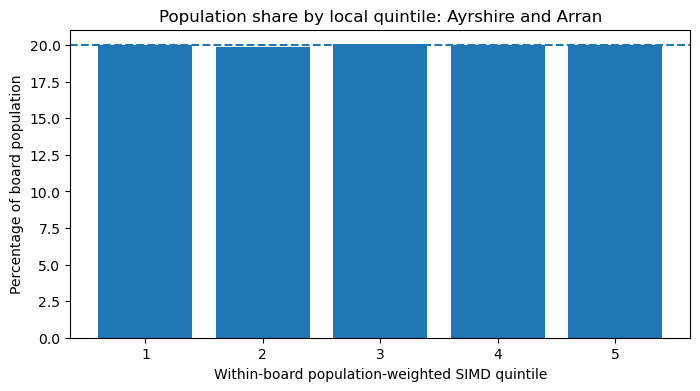

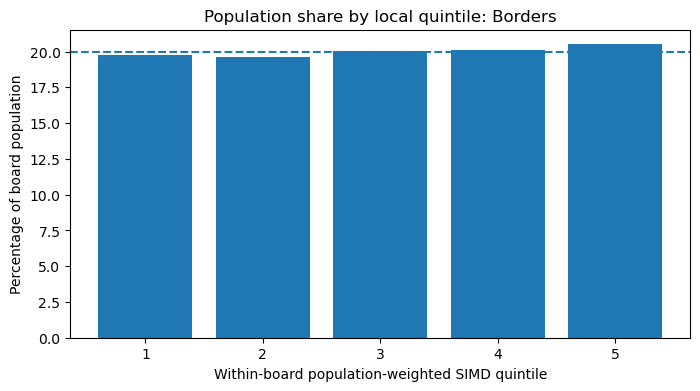

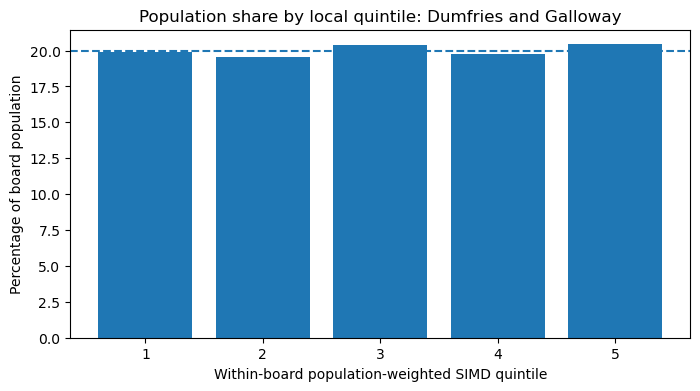

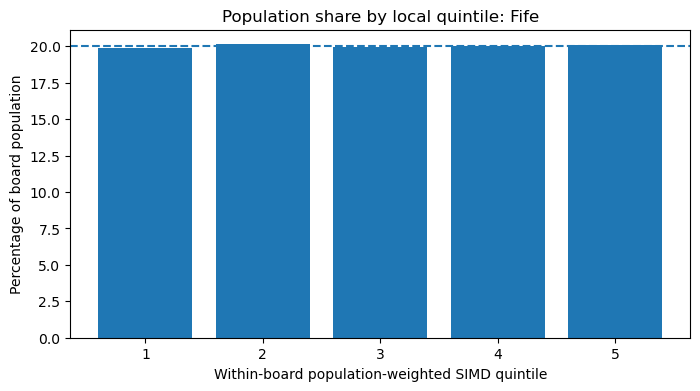

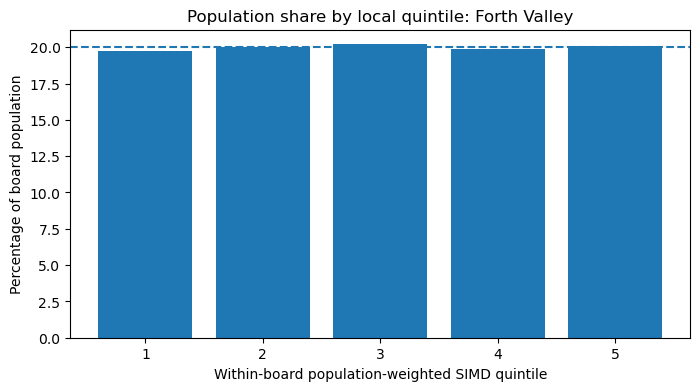

In [64]:
for board in sorted(df_local["nhs_board"].dropna().unique())[:5]:
    board_summary = local_summary[local_summary["nhs_board"] == board]

    plt.figure(figsize=(8, 4))
    plt.bar(
        board_summary["simd_quintile_within_board"],
        board_summary["pct_board_population"],
    )
    plt.axhline(20, linestyle="--")
    plt.xlabel("Within-board population-weighted SIMD quintile")
    plt.ylabel("Percentage of board population")
    plt.title(f"Population share by local quintile: {board}")
    plt.xticks([1, 2, 3, 4, 5])
    plt.show()

## 12. Apply SIMD groupings to real sequence-level data

The analysis dataset contains rolling-window cluster rows, so the notebook drops duplicate `sequence_id` values before summarising sequence records by deprivation group.

The data are loaded with `load_analysis_columns()`, using the default primary resolution and good Nextclade QC filter from `utils.data`.


In [65]:
sequence_records = load_analysis_columns(
    columns=["datazone"],
    resolution=0.3,
    qc="good",
)

simd_group_lookup = (
    df_grouped[[
        "datazone",
        "simd_rank",
        "population",
        "simd_quintile_source",
        "simd_quintile_pop_weighted",
    ]]
    .merge(
        df_local[["datazone", "simd_quintile_within_board"]],
        on="datazone",
        how="left",
    )
)

cases = (
    sequence_records
    .sort_values("collection_date")
    .drop_duplicates("sequence_id")
    .merge(simd_group_lookup, on="datazone", how="left")
)

cases.head()

,resolution,sequence_id,pango_lineage,datazone,collection_date,nextclade_qc,simd_rank,population,simd_quintile_source,simd_quintile_pop_weighted,simd_quintile_within_board
0,0.3,Scotland/CVR3946/2020,B.1.1.369,S01007678,2020-07-04,good,2273,741,2,2,2
1,0.3,Scotland/CVR3956/2020,B.1.1.369,S01007643,2020-07-13,good,5093,907,4,4,5
2,0.3,Scotland/QEUH-94384C/2020,B.1.1.10,S01011703,2020-07-13,good,5643,912,5,5,5
3,0.3,Scotland/QEUH-7A4553/2020,B.1.1,S01010154,2020-07-15,good,494,927,1,1,1
4,0.3,Scotland/CAMC-945B8D/2020,B.1.1.369,S01007680,2020-07-16,good,6424,894,5,5,5


In [66]:
case_summary = (
    cases
    .dropna(subset=["simd_quintile_pop_weighted"])
    .groupby("simd_quintile_pop_weighted")
    .agg(
        n_sequences=("sequence_id", "nunique"),
        n_datazones_observed=("datazone", "nunique"),
    )
    .reset_index()
)

case_summary["pct_sequences"] = case_summary["n_sequences"] / case_summary["n_sequences"].sum() * 100

case_summary

,simd_quintile_pop_weighted,n_sequences,n_datazones_observed,pct_sequences
0,1,64145,1429,22.801436
1,2,60144,1428,21.379212
2,3,52002,1408,18.484999
3,4,53732,1356,19.099957
4,5,51297,1350,18.234395


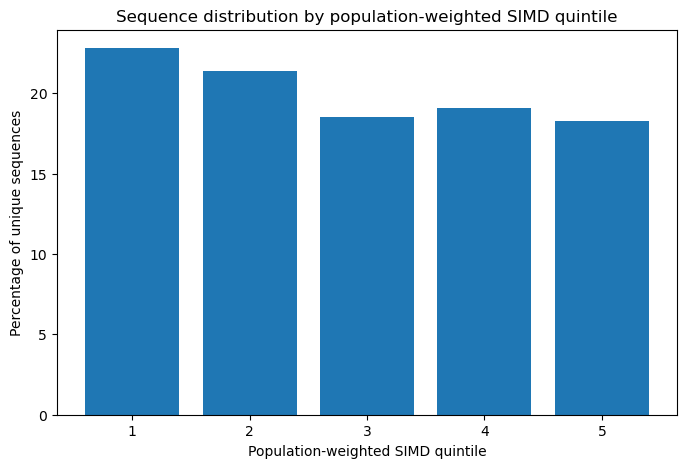

In [67]:
plt.figure(figsize=(8, 5))
plt.bar(case_summary["simd_quintile_pop_weighted"], case_summary["pct_sequences"])
plt.xlabel("Population-weighted SIMD quintile")
plt.ylabel("Percentage of unique sequences")
plt.title("Sequence distribution by population-weighted SIMD quintile")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

## Interpretation notes

- Population-weighted quintiles aim to put around 20% of the relevant population in each quintile.
- Existing SIMD quintiles and equal-Data-Zone quintiles put around 20% of Data Zones in each quintile.
- These can differ when Data Zone populations vary across the SIMD rank distribution.
- National quintiles are appropriate when comparing deprivation across Scotland.
- Local quintiles, such as within NHS Board, describe relative deprivation inside each local area and should be interpreted locally.
- Sequence summaries in this notebook describe unique sequenced cases available in the processed analysis dataset, not the full infection burden.
